# 5. Causal models: DoWhy & EconML

In [ ]:
#%pip -q install "networkx<3.0"

In [ ]:
#%pip install --upgrade dowhy

In [ ]:
#%pip -q install econml

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import dowhy
from dowhy import CausalModel

from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz
import tqdm as notebook_tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1\. 데이터 생성

\*\*구조적 인과 모델 (Structural Causal Model, SCM)\*\*은 변수들 간의 인과 관계를 일련의 함수식으로 정의하는 모델이다. 이를 통해 데이터 생성 과정을 시뮬레이션하고, 관측 데이터와 중재(intervention) 데이터를 모두 만들 수 있다.

In [3]:
# First, we'll build a structural causal model (SCM)
# 먼저, 구조적 인과 모델(SCM)을 구축합니다.
class GPSMemorySCM:

    def __init__(self, random_seed=None):
        self.random_seed = random_seed
        self.u_x = stats.truncnorm(0, np.infty, scale=5)
        self.u_y = stats.norm(scale=2)
        self.u_z = stats.norm(scale=2)
        self.u = stats.truncnorm(0, np.infty, scale=4)

    def sample(self, sample_size=100, treatment_value=None):
        """Samples from the SCM"""
        """SCM에서 샘플링합니다."""
        if self.random_seed:
            np.random.seed(self.random_seed)

        u_x = self.u_x.rvs(sample_size)
        u_y = self.u_y.rvs(sample_size)
        u_z = self.u_z.rvs(sample_size)
        u = self.u.rvs(sample_size)

        if treatment_value:
            gps = np.array([treatment_value]*sample_size)
        else:
            gps = u_x + 0.7*u

        hippocampus = -0.6*gps + 0.25*u_z
        memory = 0.7*hippocampus + 0.25*u

        return gps, hippocampus, memory

    def intervene(self, treatment_value, sample_size=100):
        """Intervenes on the SCM"""
        """SCM에 중재를 가합니다."""
        return self.sample(treatment_value=treatment_value, sample_size=sample_size)

In [4]:
# Instantiate the SCM
# SCM 인스턴스화
scm = GPSMemorySCM()

# Generate observational data
# 관측 데이터 생성
gps_obs, hippocampus_obs, memory_obs = scm.sample(1000)

# Encode as a pandas df
# pandas df로 인코딩
df = pd.DataFrame(np.vstack([gps_obs, hippocampus_obs, memory_obs]).T, columns=['X', 'Z', 'Y'])

In [5]:
df

,X,Z,Y
0,5.007370,-3.006443,-0.932174
1,4.288860,-2.542763,-0.464556
2,13.773651,-8.937942,-5.861665
3,5.184588,-2.199776,-0.210057
4,6.035431,-3.248829,-0.648077
...,...,...,...
995,2.807197,-1.539509,-0.311395
996,3.691380,-2.492225,-1.401823
997,10.288951,-6.463580,-2.631990
998,4.279332,-2.280336,-0.968058


## 2\. 인과 추론의 4단계

`DoWhy` 라이브러리는 인과추론을 위한 4단계 접근법을 제공한다:

1.  **모델링(Modeling)**
2.  **식별(Identification)**
3.  **추정(Estimation)**
4.  **반박(Refutation)**

## 1단계: 문제 모델링

### 1.1단계 - 그래프 정의 - `GML`

In [6]:
# Create the graph describing the causal structure
# 인과 구조를 설명하는 그래프 생성
gml_graph = """
graph [
    directed 1

    node [
        id "X"
        label "X"
    ]
    node [
        id "Z"
        label "Z"
    ]
    node [
        id "Y"
        label "Y"
    ]
    node [
        id "U"
        label "U"
    ]

    edge [
        source "X"
        target "Z"
    ]
    edge [
        source "Z"
        target "Y"
    ]
    edge [
        source "U"
        target "X"
    ]
    edge [
        source "U"
        target "Y"
    ]
]
"""

### 1.2단계 - DoWhy 모델 정의

`dowhy`의 `CausalModel` 클래스를 사용하여 인과 모델을 생성한다.

  * `data`: 분석에 사용할 데이터프레임 `df`를 지정한다.
  * `treatment`: 처리 변수로 'X'(GPS 사용량)를 지정한다.
  * `outcome`: 결과 변수로 'Y'(기억력)를 지정한다.
  * `graph`: 앞서 GML 형식으로 정의한 `gml_graph`를 인과 그래프로 사용한다.

In [7]:
# With graph
# 그래프와 함께
model = CausalModel(
    data=df,
    treatment='X',
    outcome='Y',
    graph=gml_graph
)

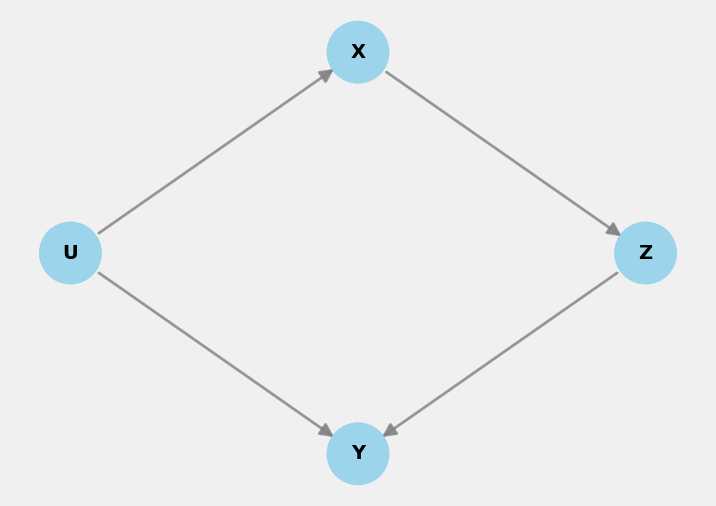

In [8]:
model.view_model()

## 2단계: Estimand 식별

`model.identify_effect()` 메서드를 호출하여 X가 Y에 미치는 인과 효과(ATE: Average Treatment Effect)에 대한 estimand를 식별한다. `DoWhy`는 do-calculus 규칙을 적용하여 주어진 그래프에서 통계적으로 추정 가능한 식을 찾는다.

In [10]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
No such variable(s) found!

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
Estimand expression:
 ⎡ d       d       ⎤
E⎢────(Y)⋅────([Z])⎥
 ⎣d[Z]    d[X]     ⎦
Estimand assumption 1, Full-mediation: Z intercepts (blocks) all directed paths from X to Y.
Estimand assumption 2, First-stage-unconfoundedness: If U→{X} and U→{Z} then P(Z|X,U) = P(Z|X)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{Z} and U→Y then P(Y|Z, X, U) = P(Y|Z, X)



## 3단계: 인과 효과 추정

#### 선형 회귀

`model.estimate_effect()` 메서드를 사용하여 식별된 estimand로부터 실제 인과 효과를 추정한다.

  * `identified_estimand`: 2단계에서 식별한 estimand 객체를 전달한다.
  * `method_name='frontdoor.two_stage_regression'`: 전면 기준을 위한 2단계 회귀 분석 방법을 사용하여 추정하도록 지정한다. 이 방법은 선형성을 가정하고 두 개의 회귀 모델을 통해 인과 효과를 계산한다.

In [11]:
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='frontdoor.two_stage_regression')

print(f'Estimate of causal effect (linear regression): {estimate.value}')

Estimate of causal effect (linear regression): -0.4357351849005123


## 4단계: 반박 테스트 실행

추정된 인과 효과의 강건성을 검증하기 위해 반박 테스트(refutation test)를 수행한다. `model.refute_estimate()` 메서드를 사용하며, `data_subset_refuter` 방법은 데이터를 무작위로 샘플링한 하위 집합에서도 추정치가 유사하게 유지되는지를 검증한다.

In [12]:
refute_subset = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.4)

In [14]:
print(refute_subset)

Refute: Use a subset of data
Estimated effect:-0.4357351849005123
New effect:-0.4340719095256116
p value:0.96



## 3\. 전체 예시

`graphviz`를 사용하여 S, Q, X, Y, P 5개의 노드로 구성된 더 복잡한 인과 그래프를 생성하고 시각화한다. 이 그래프는 여러 개의 교란 경로와 인과 경로가 얽혀 있는 상황을 모델링한다.

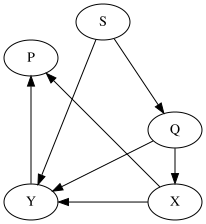

In [15]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['S', 'Q', 'X', 'Y', 'P']
positions = ['2,2.5!', '3,1!', '3,0!', '1, 0!', '1,2!', '1.7,0.9!']

edges = ['SQ', 'SY', 'QX', 'QY', 'XP', 'YP', 'XY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_07_full_example')

graph

In [16]:
SAMPLE_SIZE = 1000

S = np.random.random(SAMPLE_SIZE)
Q = 0.2*S + 0.67*np.random.random(SAMPLE_SIZE)
X = 0.14*Q + 0.4*np.random.random(SAMPLE_SIZE)
Y = 0.7*X + 0.11*Q + 0.32*S + 0.24*np.random.random(SAMPLE_SIZE)
P = 0.43*X + 0.21*Y + 0.22*np.random.random(SAMPLE_SIZE)

# Encode as a pandas df
# pandas df로 인코딩
df = pd.DataFrame(np.vstack([S, Q, X, Y, P]).T, columns=['S', 'Q', 'X', 'Y', 'P'])

In [17]:
# Generate the GML graph
# GML 그래프 생성
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

In [18]:
print(gml_string)

graph [directed 1
	node [id "S" label "S"]
	node [id "Q" label "Q"]
	node [id "X" label "X"]
	node [id "Y" label "Y"]
	node [id "P" label "P"]
	edge [source "S" target "Q"]
	edge [source "S" target "Y"]
	edge [source "Q" target "X"]
	edge [source "Q" target "Y"]
	edge [source "X" target "P"]
	edge [source "Y" target "P"]
	edge [source "X" target "Y"]
]


In [19]:
# Instantiate the CausalModel
# CausalModel 인스턴스화
model = CausalModel(
    data=df,
    treatment='X',
    outcome='Y',
    graph=gml_string
)

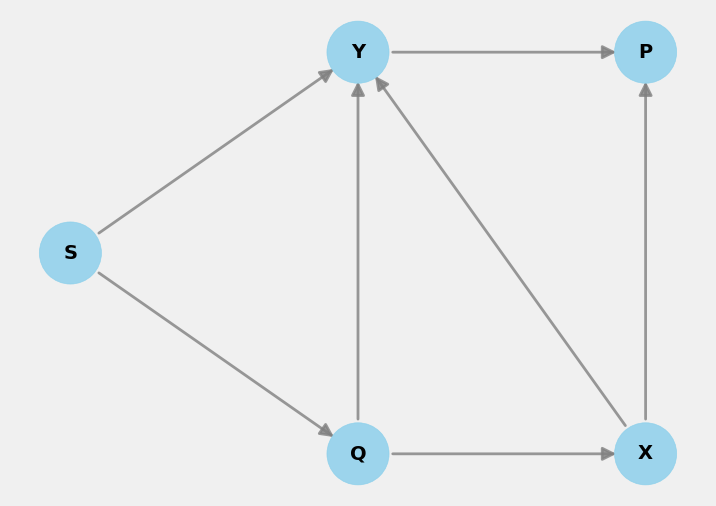

In [20]:
model.view_model()

In [21]:
# Get the estimand
# estimand 얻기
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|Q])
d[X]        
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,Q,U) = P(Y|X,Q)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



`EconML` 라이브러리의 **DML(Double Machine Learning)** 방법을 사용하여 인과 효과를 추정한다.

  * `method_name='backdoor.econml.dml.DML'`: 후문 기준을 만족시키는 estimand를 DML 방법으로 추정하도록 지정한다.
  * `method_params`: DML에 사용할 머신러닝 모델들을 지정한다.
      * `model_y`: 결과(Y)를 예측하는 모델로 `GradientBoostingRegressor`를 사용한다.
      * `model_t`: 처리(X)를 예측하는 모델로 `GradientBoostingRegressor`를 사용한다.
      * `model_final`: 마지막 단계에서 인과 효과를 추정하는 모델로 `LassoCV`를 사용한다.

In [22]:
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.DML',
    method_params={
        'init_params': {
            'model_y': GradientBoostingRegressor(),
            'model_t': GradientBoostingRegressor(),
            'model_final': LassoCV(fit_intercept=False),
        },
        'fit_params': {}}
)

print(f'Estimate of causal effect (DML): {estimate.value}')

Estimate of causal effect (DML): 0.6414177737651319


In [23]:
estimate_lr = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.linear_regression')

print(f'Estimate of causal effect (linear regression): {estimate_lr.value}')

Estimate of causal effect (linear regression): 0.6735607320228905


In [24]:
random_cause = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name='random_common_cause'
)

In [25]:
print(random_cause)

Refute: Add a random common cause
Estimated effect:0.6414177737651319
New effect:0.6506436007745223
p value:0.54



In [26]:
placebo_refuter = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name='placebo_treatment_refuter'
)

In [27]:
print(placebo_refuter)

Refute: Use a Placebo Treatment
Estimated effect:0.6414177737651319
New effect:0.0
p value:1.0



## 4\. GCM API

\*\*GCM (Graphical Causal Models)\*\*은 `DoWhy`의 최신 API로, SCM(구조적 인과 모델)을 직접 다루며 개별 변수의 인과 메커니즘을 모델링하고 반사실적(counterfactual) 추론을 가능하게 한다.

In [28]:
import networkx as nx
from dowhy import gcm

In [29]:
SAMPLE_SIZE = 1000

S = np.random.random(SAMPLE_SIZE)
Q = 0.2*S + 0.67*np.random.random(SAMPLE_SIZE)
X = 0.14*Q + 0.4*np.random.random(SAMPLE_SIZE)
Y = 0.7*X + 0.11*Q + 0.32*S + 0.24*np.random.random(SAMPLE_SIZE)
P = 0.43*X + 0.21*Y + 0.22*np.random.random(SAMPLE_SIZE)

# Encode as a pandas df
# pandas df로 인코딩
df = pd.DataFrame(np.vstack([S, Q, X, Y, P]).T, columns=['S', 'Q', 'X', 'Y', 'P'])

In [30]:
edges = ['SQ', 'SY', 'QX', 'QY', 'XP', 'YP', 'XY']
graph_nx = nx.DiGraph([(edge[0], edge[1]) for edge in edges])

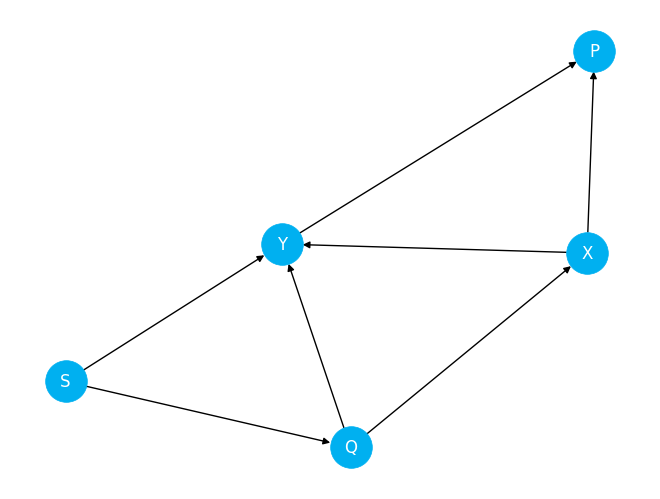

In [31]:
nx.draw(
    graph_nx,
    with_labels=True,
    node_size=900,
    font_color='white',
    node_color=COLORS[0]
)

In [32]:
causal_model = gcm.InvertibleStructuralCausalModel(graph_nx)

In [33]:
causal_model.set_causal_mechanism('S', gcm.EmpiricalDistribution())
causal_model.set_causal_mechanism('X', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('Y', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('P', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))
causal_model.set_causal_mechanism('Q', gcm.AdditiveNoiseModel(gcm.ml.create_linear_regressor()))

gcm.fit(causal_model, df)

Fitting causal mechanism of node P: 100%|██████████| 5/5 [00:00<00:00, 331.71it/s]


In [34]:
gcm.arrow_strength(causal_model, 'Y')

{('Q', 'Y'): 0.0003392467269313622,
 ('S', 'Y'): 0.008758393738279434,
 ('X', 'Y'): 0.007452463961327012}

In [35]:
gcm.counterfactual_samples(
    causal_model,
    {'X': lambda x: .21},
    observed_data=pd.DataFrame(data=dict(X=[.5], Y=[.75], S=[.5], Q=[.4], P=[.34])))

,S,Q,X,Y,P
0,0.5,0.4,0.21,0.540237,0.169129
